# Auto-Encoding Variational Bayes — Reproduction
**Paper:** Kingma & Welling, 2014  
**Assignment:** Advanced Statistical Inference, EURECOM 2026

We reproduce the main experiment of the paper: training a VAE on MNIST with different latent space dimensions (Nz = 2, 10, 20), and comparing the variational lower bound over training.

## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Dataset

We use the MNIST dataset (28x28 binary/grayscale images of handwritten digits).  
Images are flattened to vectors of size 784 and normalized to [0, 1].

In [2]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]

Train size: 60000, Test size: 10000


## 3. Model Architecture

### Encoder
The encoder $q_\phi(z|x)$ maps an input $x \in \mathbb{R}^{784}$ to a Gaussian distribution in the latent space.  
It outputs $\mu$ and $\log\sigma^2$ (one per latent dimension), implemented as a simple MLP with one hidden layer of 400 units.

### Reparameterization Trick
To backpropagate through the sampling step, we use:  
$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

### Decoder
The decoder $p_\theta(x|z)$ maps a latent vector $z$ back to a Bernoulli distribution over pixels.  
It outputs pixel probabilities via a sigmoid activation.

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # --- Encoder ---
        self.fc1    = nn.Linear(input_dim, hidden_dim)
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)   # mean
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim) # log variance

        # --- Decoder ---
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        """Returns mu and log_var of the approximate posterior q(z|x)."""
        h = F.tanh(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, log_var):
        """Reparameterization trick: z = mu + std * epsilon."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)  # epsilon ~ N(0, I)
        return mu + std * eps

    def decode(self, z):
        """Returns pixel probabilities from latent code z."""
        h = F.tanh(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)  # flatten 28x28 -> 784
        mu, log_var = self.encode(x_flat)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var

## 4. Loss Function (ELBO)

The objective to **maximize** is the Evidence Lower BOund (ELBO), which decomposes into:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{reconstruction term}} - \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{regularization term}}$$

- **Reconstruction term**: binary cross-entropy between input and reconstruction  
- **KL term**: closed-form when both prior and posterior are Gaussian:
$$D_{KL} = -\frac{1}{2} \sum_j \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

We **minimize** the negative ELBO.

In [4]:
def elbo_loss(x_recon, x, mu, log_var):
    """
    Negative ELBO = reconstruction loss + KL divergence.

    Args:
        x_recon : reconstructed image probabilities (batch_size, 784)
        x       : original images, flattened (batch_size, 784)
        mu      : mean of q(z|x)
        log_var : log variance of q(z|x)
    Returns:
        Total loss (scalar), reconstruction loss, KL divergence
    """
    x_flat = x.view(x.size(0), -1)

    # Binary cross-entropy (sum over pixels, mean over batch)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum') / x.size(0)

    # KL divergence (closed form for Gaussian)
    # = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    return recon_loss + kl_div, recon_loss, kl_div

## 5. Training

We train VAEs with different latent dimensions (Nz = 2, 10, 20) for 30 epochs.  
Optimizer: Adam (lr = 1e-3), consistent with modern practice (the original paper used Adagrad).

In [5]:
def train_epoch(model, optimizer, loader):
    model.train()
    total_loss = 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, log_var = model(x)
        loss, _, _ = elbo_loss(x_recon, x, mu, log_var)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    for x, _ in loader:
        x = x.to(device)
        x_recon, mu, log_var = model(x)
        loss, _, _ = elbo_loss(x_recon, x, mu, log_var)
        total_loss += loss.item()
    return total_loss / len(loader)

In [6]:
LATENT_DIMS = [2, 10, 20]
N_EPOCHS    = 30
HIDDEN_DIM  = 400
LR          = 1e-3

results = {}   # store train/test curves per Nz
models  = {}   # store trained models

for nz in LATENT_DIMS:
    print(f'\n=== Training VAE with Nz = {nz} ===')
    model = VAE(latent_dim=nz, hidden_dim=HIDDEN_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses, test_losses = [], []

    for epoch in tqdm(range(1, N_EPOCHS + 1)):
        train_loss = train_epoch(model, optimizer, train_loader)
        test_loss  = eval_epoch(model, test_loader)
        train_losses.append(-train_loss)  # store ELBO (not loss), so we negate
        test_losses.append(-test_loss)

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d} | Train ELBO: {-train_loss:.2f} | Test ELBO: {-test_loss:.2f}')

    results[nz] = {'train': train_losses, 'test': test_losses}
    models[nz] = model

print('\nTraining complete!')


=== Training VAE with Nz = 2 ===


 33%|███▎      | 10/30 [01:27<02:52,  8.61s/it]

  Epoch  10 | Train ELBO: -155.47 | Test ELBO: -155.63


 67%|██████▋   | 20/30 [02:53<01:25,  8.52s/it]

  Epoch  20 | Train ELBO: -150.11 | Test ELBO: -151.47


...

  Epoch  10 | Train ELBO: -108.49 | Test ELBO: -107.31


 67%|██████▋   | 20/30 [02:50<01:24,  8.48s/it]

  Epoch  20 | Train ELBO: -104.77 | Test ELBO: -104.39


100%|██████████| 30/30 [04:16<00:00,  8.55s/it]

  Epoch  30 | Train ELBO: -103.37 | Test ELBO: -103.43

Training complete!


## 6. Results — Variational Lower Bound

We plot the ELBO (variational lower bound) during training for each Nz.  
Higher is better. This reproduces the spirit of Figure 2 from the original paper.

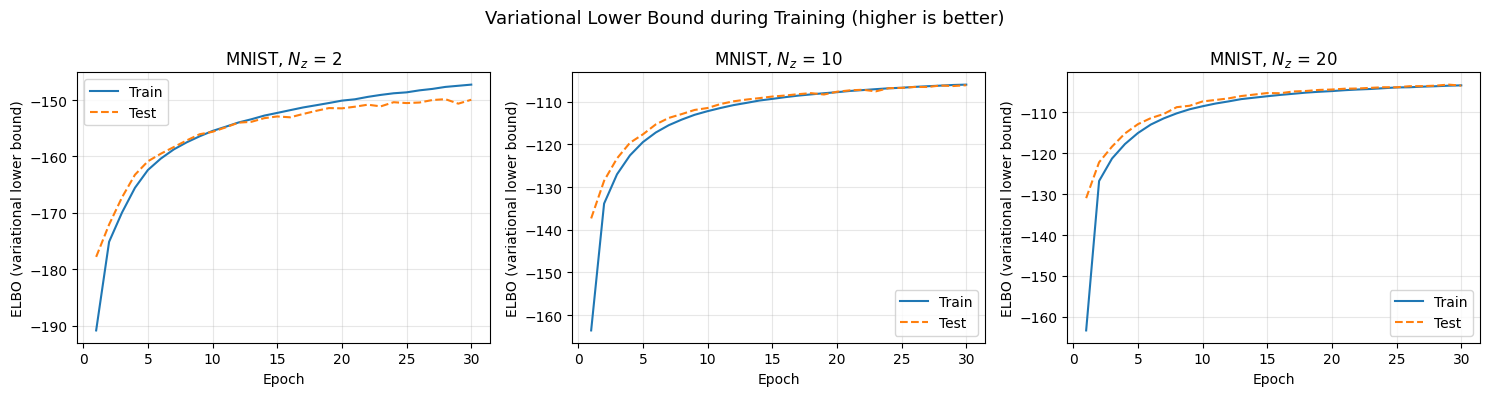

Figure saved as elbo_curves.png


In [7]:
fig, axes = plt.subplots(1, len(LATENT_DIMS), figsize=(15, 4), sharey=False)

for ax, nz in zip(axes, LATENT_DIMS):
    epochs = range(1, N_EPOCHS + 1)
    ax.plot(epochs, results[nz]['train'], label='Train', color='tab:blue')
    ax.plot(epochs, results[nz]['test'],  label='Test',  color='tab:orange', linestyle='--')
    ax.set_title(f'MNIST, $N_z$ = {nz}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('ELBO (variational lower bound)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Variational Lower Bound during Training (higher is better)', fontsize=13)
plt.tight_layout()
plt.savefig('elbo_curves.pdf', bbox_inches='tight')
plt.savefig('elbo_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as elbo_curves.png')

## 7. Generated Samples

We sample $z \sim \mathcal{N}(0, I)$ and decode to get generated images.  
This shows the quality of the generative model $p_\theta(x|z)$.

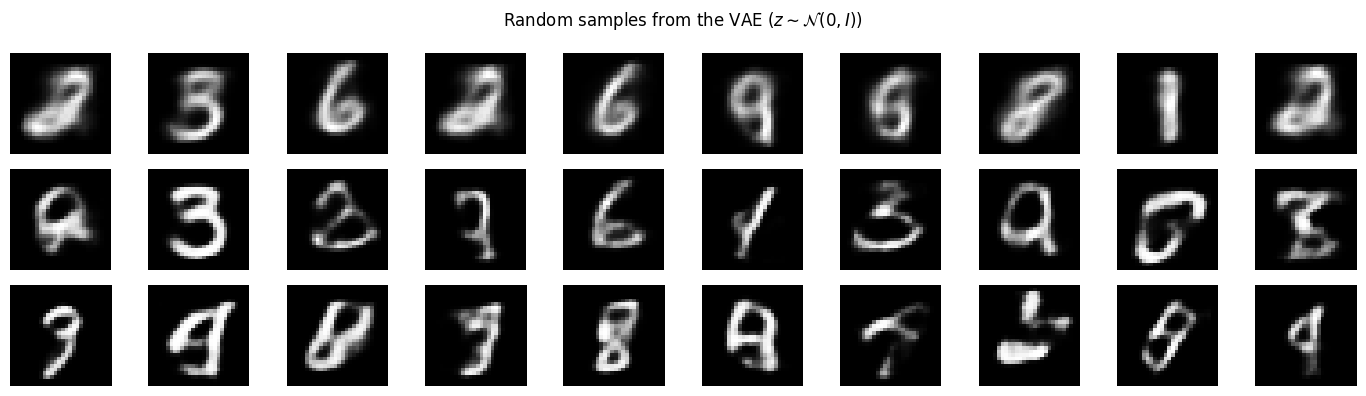

Figure saved as generated_samples.png


In [8]:
fig, axes = plt.subplots(len(LATENT_DIMS), 10, figsize=(14, 4))

for row, nz in enumerate(LATENT_DIMS):
    model = models[nz]
    model.eval()
    with torch.no_grad():
        z = torch.randn(10, nz).to(device)
        samples = model.decode(z).cpu().view(10, 28, 28)

    for col in range(10):
        axes[row, col].imshow(samples[col], cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'$N_z$={nz}', fontsize=11, rotation=90, labelpad=40)

plt.suptitle('Random samples from the VAE ($z \\sim \\mathcal{N}(0,I)$)', fontsize=12)
plt.tight_layout()
plt.savefig('generated_samples.pdf', bbox_inches='tight')
plt.savefig('generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as generated_samples.png')

## 8. Latent Space Visualization (Nz = 2)

When the latent space is 2D, we can directly visualize where different digit classes are encoded.  
This reproduces the spirit of Figures 4 and 5 from the paper.

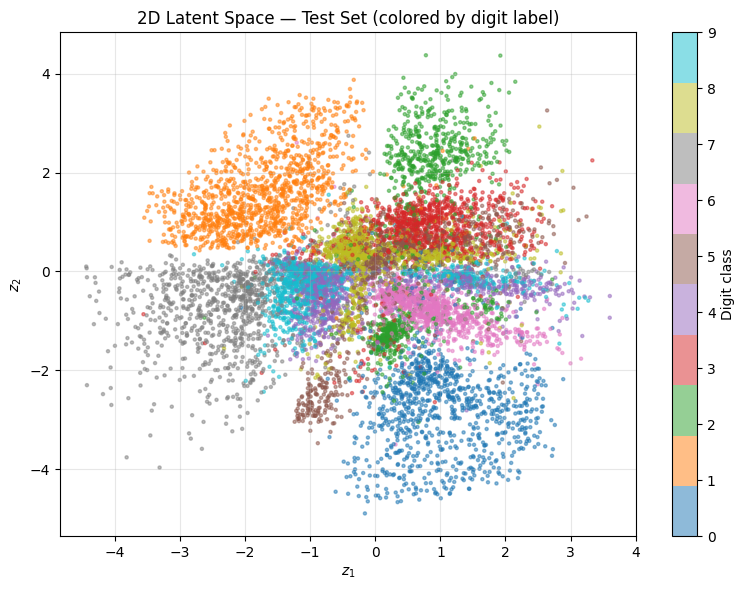

Figure saved as latent_space_2d.png


In [9]:
model_2d = models[2]
model_2d.eval()

all_z, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model_2d.encode(x.view(x.size(0), -1))
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_z      = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1],
                      c=all_labels, cmap='tab10',
                      alpha=0.5, s=5)
plt.colorbar(scatter, label='Digit class')
plt.xlabel('$z_1$')
plt.ylabel('$z_2$')
plt.title('2D Latent Space — Test Set (colored by digit label)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('latent_space_2d.pdf', bbox_inches='tight')
plt.savefig('latent_space_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as latent_space_2d.png')

## 9. Latent Space Manifold (Nz = 2)

We decode a regular grid of points in the 2D latent space (after passing through the inverse CDF of the Gaussian) to see how the model interpolates between digit classes.  
This directly reproduces Figure 4b of the paper.

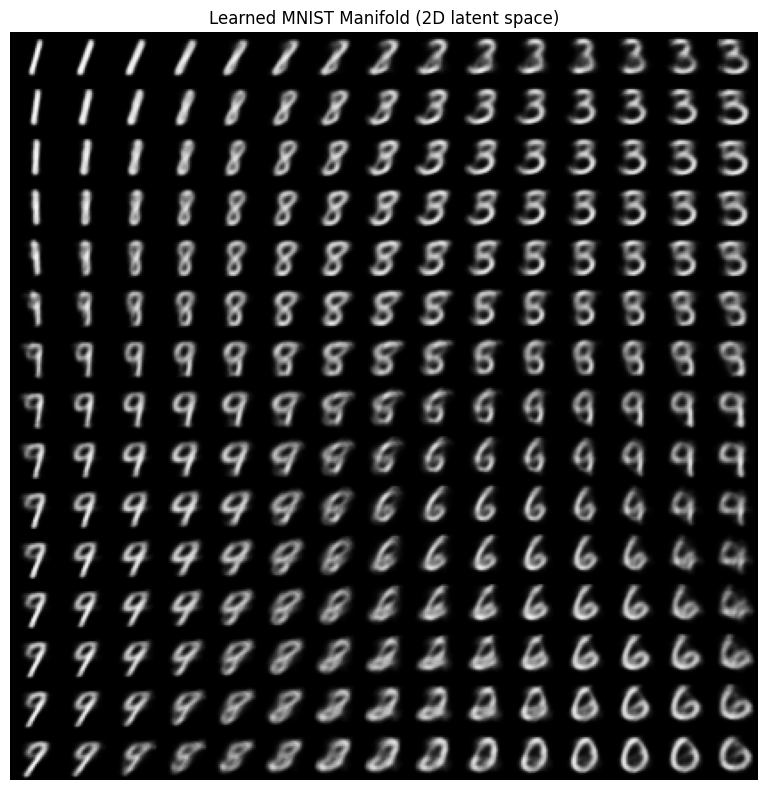

Figure saved as latent_manifold_2d.png


In [10]:
from scipy.stats import norm

n_grid = 15  # number of points per axis
grid_range = np.linspace(0.05, 0.95, n_grid)  # uniform in [0,1] -> inverse CDF

# Build grid of latent points using the inverse CDF (ppf) of N(0,1)
z_grid = []
for yi in grid_range:
    for xi in grid_range:
        z_grid.append([norm.ppf(xi), norm.ppf(yi)])

z_grid = torch.tensor(z_grid, dtype=torch.float32).to(device)

model_2d.eval()
with torch.no_grad():
    decoded = model_2d.decode(z_grid).cpu().view(-1, 28, 28).numpy()

# Tile into a single image
canvas = np.zeros((n_grid * 28, n_grid * 28))
idx = 0
for i in range(n_grid):
    for j in range(n_grid):
        canvas[(n_grid-1-i)*28:(n_grid-i)*28, j*28:(j+1)*28] = decoded[idx]
        idx += 1

plt.figure(figsize=(8, 8))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title('Learned MNIST Manifold (2D latent space)', fontsize=12)
plt.tight_layout()
plt.savefig('latent_manifold_2d.pdf', bbox_inches='tight')
plt.savefig('latent_manifold_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as latent_manifold_2d.png')

## 10. Reconstruction Quality

Visual comparison between original test images and their reconstructions for each Nz.

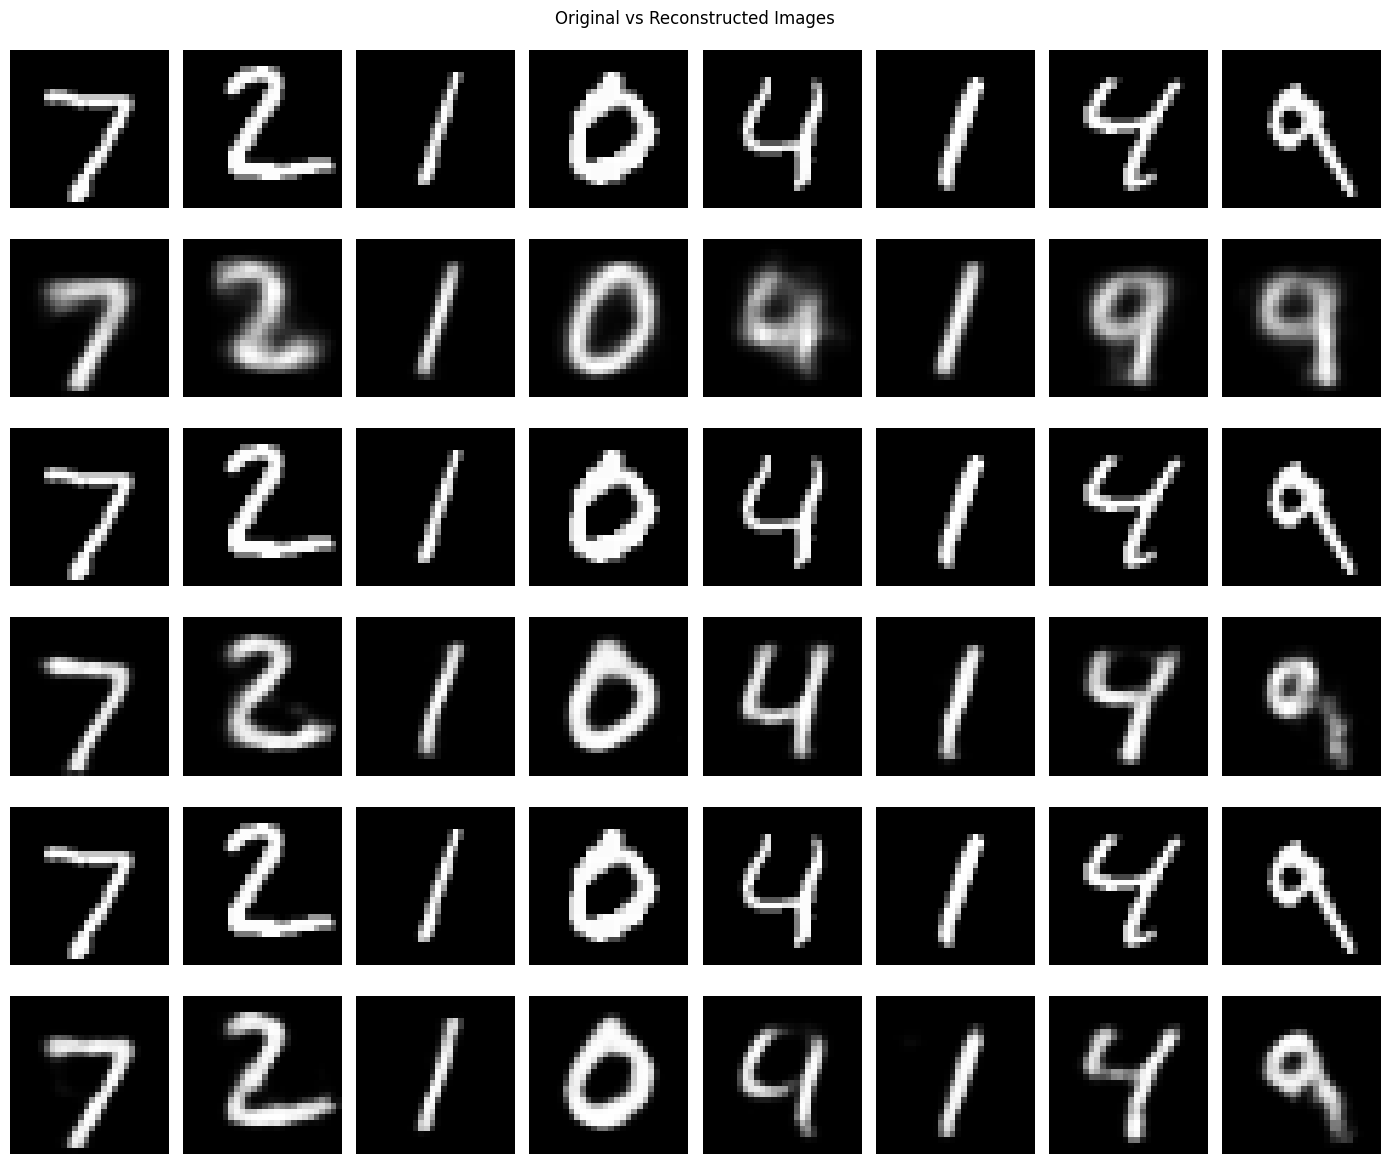

Figure saved as reconstructions.png


In [11]:
# Get a fixed batch from the test set
test_x, _ = next(iter(test_loader))
test_x = test_x[:8].to(device)

fig, axes = plt.subplots(len(LATENT_DIMS) * 2, 8, figsize=(14, 4 * len(LATENT_DIMS)))

for row_pair, nz in enumerate(LATENT_DIMS):
    model = models[nz]
    model.eval()
    with torch.no_grad():
        x_recon, _, _ = model(test_x)
        x_recon = x_recon.cpu().view(-1, 28, 28)

    orig = test_x.cpu().view(-1, 28, 28)

    for col in range(8):
        row_orig  = row_pair * 2
        row_recon = row_pair * 2 + 1

        axes[row_orig,  col].imshow(orig[col],         cmap='gray')
        axes[row_recon, col].imshow(x_recon[col].numpy(), cmap='gray')
        axes[row_orig,  col].axis('off')
        axes[row_recon, col].axis('off')

    axes[row_pair * 2,     0].set_ylabel(f'Original\n(Nz={nz})',      fontsize=9)
    axes[row_pair * 2 + 1, 0].set_ylabel(f'Reconstructed\n(Nz={nz})', fontsize=9)

plt.suptitle('Original vs Reconstructed Images', fontsize=12)
plt.tight_layout()
plt.savefig('reconstructions.pdf', bbox_inches='tight')
plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as reconstructions.png')

## 11. Summary Table — Final ELBO values

In [12]:
print('='*50)
print(f'{"Nz":>5} | {"Train ELBO":>12} | {"Test ELBO":>12}')
print('-'*50)
for nz in LATENT_DIMS:
    train_final = results[nz]['train'][-1]
    test_final  = results[nz]['test'][-1]
    print(f'{nz:>5} | {train_final:>12.2f} | {test_final:>12.2f}')
print('='*50)
print('(Higher ELBO = better)')

   Nz |   Train ELBO |    Test ELBO
--------------------------------------------------
    2 |      -147.27 |      -149.95
   10 |      -106.00 |      -106.14
   20 |      -103.37 |      -103.43
(Higher ELBO = better)
